# Analyse the dataset resulting from manual analysis

In [1]:
import pyphysics as phys
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak
import hist
import pandas as pd
import ROOT

Label data

In [2]:
df = pd.read_csv("./events_f0.csv")
df = df[df["type"].notna()]
types = df["type"].unique()
df.head()

,run,entry,type,status
0,31,87,Other,False
1,31,93,Binary,True
2,31,141,Binary,True
3,31,151,Binary,True
4,31,184,Binary,True


ROOT data

In [3]:
rdf = ROOT.RDataFrame("SimpleTree", "./Outputs/simple_tree.root") #type: ignore
rak = ak.from_rdataframe(rdf, columns=("Ef0"))
# Get classified events
rak_notna = rak[:df.index[-1] + 1]

Plot distribution of Si f0 energies depending on event type

In [21]:
ax = hist.axis.Regular(100, 0, 20, name="e", label=r"$E_{sil}$ [MeV]") 
tax = hist.axis.StrCategory(categories=types, name="t")
h = hist.Hist(ax, tax)


In [22]:
binary = df[df["type"] == "Binary"]
multi = df[df["type"] == "Multi"]
other = df[df["type"] == "Other"]

h.fill(e=rak_notna[binary.index], t="Binary")
h.fill(e=rak_notna[multi.index], t="Multi")
h.fill(e=rak_notna[other.index], t="Other")

Hist(
  Regular(100, 0, 20, name='e', label='$E_{sil}$ [MeV]'),
  StrCategory(['Other', 'Binary', 'Multi'], name='t'),
  storage=Double()) # Sum: 495.0 (500.0 with flow)

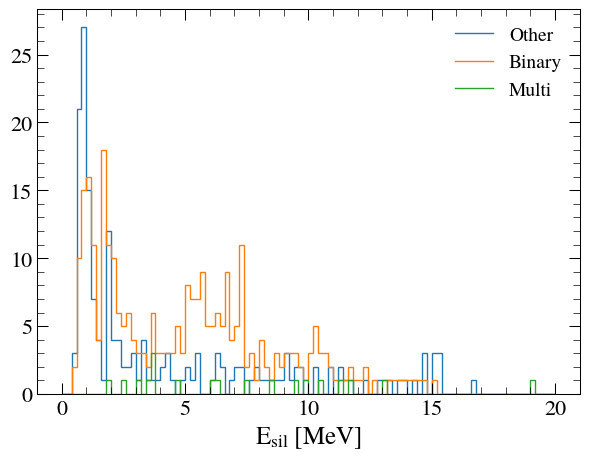

In [23]:
stack = h.stack("t")
stack.plot(histtype="step", yerr=False)
plt.legend()